# DEVELOPMENT OF THE FINITE DIFFERENCE METHOD ANALYSIS FOR VORTICITY FLOW SIMULATION
## Name : Aldiansyah Anugrah Ramadhan

## Library 

In [1]:
import os

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

## Folder Configuration

In [2]:
csv_dir = os.path.join('.', 'output', 'csv')
fig_dir = os.path.join('.', 'output', 'figure')
animation_dir = os.path.join('.', 'output', 'animation')

## Fluid Mechanics

### Reynolds Number

\begin{equation}
Re = \frac{UL}{\nu}
\end{equation}

### Vorticity Transport Equation

\begin{equation}
\frac{{\partial {\omega}}}{{\partial t}} + \frac{{\partial \psi }}{{\partial y}}\frac{{\partial {\omega}}}{{\partial x}} - \frac{{\partial \psi }}{{\partial x}}\frac{{\partial {\omega}}}{{\partial y}} = \nu (\frac{{\partial^{2} {\omega}}}{{\partial x^{2}}} + \frac{{\partial^{2} {\omega}}}{{\partial y^{2}}})
\end{equation}

### Poisson Equation

\begin{equation}
\frac{{\partial^{2} {\psi}}}{{\partial x^{2}}} + \frac{{\partial^{2} {\psi}}}{{\partial y^{2}}} = -\omega
\end{equation}

## Fourth-Order Runge-Kutta Method

\begin{equation}
	\frac{d\omega}{dt} =  f(t, \omega)
\end{equation}

\begin{equation}
	\omega^{n+1} = \omega^{n} + \frac{1}{6}(k_{1} + 2k_{2} + 2k_{3} + k_{4})
\end{equation}

\begin{align}
	k_{1} &= f(t, \omega)\Delta t \\
	k_{2} &= f\left(t + \frac{\Delta t}{2}, \omega + \frac{k_{1}}{2}\right)\Delta t \\
	k_{3} &= f\left(t + \frac{\Delta t}{2}, \omega + \frac{k_{2}}{2}\right)\Delta t \\
	k_{4} &= f(t + \Delta t, \omega + k_{3})\Delta t
\end{align}

## Finite Difference Method

### FTCS Scheme

\begin{equation}
	\frac{\partial u}{\partial x}\bigg|_{i,j}^n \approx \frac{u_{i+1,j}^n - u_{i-1,j}^n}{2\Delta x}
\end{equation}

\begin{equation}
	\frac{\partial u}{\partial y}\bigg|_{i,j}^n \approx \frac{u_{i,j+1}^n - u_{i,j-1}^n}{2\Delta y}
\end{equation}

\begin{equation}
	\frac{\partial^2 u}{\partial x^2}\bigg|_{i,j}^n \approx \frac{u_{i+1,j}^n - 2u_{i,j}^n + u_{i-1,j}^n}{\Delta x^2}
\end{equation}

\begin{equation}
	\frac{\partial^2 u}{\partial y^2}\bigg|_{i,j}^n \approx \frac{u_{i,j+1}^n - 2u_{i,j}^n + u_{i,j-1}^n}{\Delta y^2}
\end{equation}

\begin{equation}
	\frac{\partial u}{\partial t}\bigg|_{i,j}^n \approx \frac{u_{i,j}^{n+1} - u_{i,j}^n}{\Delta t}
\end{equation}

### Poisson Equation Discritization

\begin{equation}
\frac{{\psi_{i+1,j}^n - 2\psi_{i,j}^n + \psi_{i-1,j}^n}}{{\Delta {x^2}}} + \frac{{\psi_{i,j+1}^n - 2\psi_{i,j}^n + \psi_{i,j-1}^n}}{{\Delta {y^2}}} = -\omega_{i,j}^{n}
\end{equation}

\begin{equation}
\psi_{i,j}^{(k+1)} = \frac{\Delta{x^2}\Delta{y^2}}{2(\Delta{x^2}+\Delta{y^2})}\omega_{i,j}^{n} + \frac{\Delta y^{2}}{2(\Delta{x^2}+\Delta{y^2})}(\psi_{i+1,j}^{(k)} + \psi_{i-1,j}^{(k)}) + \frac{\Delta x^{2}}{2(\Delta{x^2}+\Delta{y^2})}({\psi_{i,j+1}^{(k)} + \psi_{i,j-1}^{(k)}})
\end{equation}

Point Succesive Over Relaxation (PSOR) Algorithm

\begin{equation}
\psi_{i,j}^{(k+1)} = \frac{\beta\Delta{x^2}\Delta{y^2}}{2(\Delta{x^2}+\Delta{y^2})}\omega_{i,j}^{n} + \frac{\beta\Delta y^{2}}{2(\Delta{x^2}+\Delta{y^2})}(\psi_{i+1,j}^{(k)} + \psi_{i-1,j}^{(k)}) + \frac{\beta\Delta x^{2}}{2(\Delta{x^2}+\Delta{y^2})}({\psi_{i,j+1}^{(k)} + \psi_{i,j-1}^{(k)}}) + (1-\beta)\psi_{i,j}^{(k)}
\end{equation}

### Vorticity Transport Equation Discritization

#### FTCS Scheme

\begin{equation}
C_{x} =  \left( {\frac{{\psi_{i,j+1}^n - \psi_{i,j-1}^n}}{{2\Delta y}}} \right)\left( {\frac{{\omega_{i+1,j}^n - \omega_{i-1,j}^n}}{{2\Delta x}}} \right)
\end{equation}

\begin{equation}
C_{y} = \left( {\frac{{\psi_{i+1,j}^n - \psi _{i-1,j}^n}}{{2\Delta x}}} \right)\left( {\frac{{\omega_{i,j+1}^n - \omega_{i,j-1}^n}}{{2\Delta y}}} \right)
\end{equation}

\begin{equation}
D_{xy} = \frac{{\omega_{i+1,j}^n - 2\omega_{i,j}^n + \omega _{i-1,j}^n}}{{\Delta {x^2}}} + \frac{{\omega_{i,j+1}^n - 2\omega_{i,j}^n + \omega_{i,j-1}^n}}{{\Delta {y^2}}}
\end{equation}

\begin{equation}
\omega_{i,j}^{n+1} = (\nu D_{xy} - C_{x} + C_{y})\Delta t + \omega_{i,j}^{n}
\end{equation}

#### RK4-CS Scheme

\begin{equation}
		\begin{split}
			\frac{d\omega_{i,j}}{dt} = {} & \nu \left( \frac{\omega_{i+1,j} - 2\omega_{i,j} + \omega_{i-1,j}}{\Delta x^2} + \frac{\omega_{i,j+1} - 2\omega_{i,j} + \omega_{i,j-1}}{\Delta y^2} \right) \\
			&- \left( \frac{\psi_{i,j+1} - \psi_{i,j-1}}{2\Delta y} \right) \left( \frac{\omega_{i+1,j} - \omega_{i-1,j}^n}{2\Delta x} \right) \\
			&+ \left( \frac{\psi_{i+1,j} - \psi_{i-1,j}}{2\Delta x} \right) \left( \frac{\omega_{i,j+1} - \omega_{i,j-1}^n}{2\Delta y} \right)
		\end{split}
\end{equation}

## Kondisi Awal

## Simulation

In [3]:
def initial_solution(nx, ny):
  psi_init = np.zeros([ny+1,nx+1])
  omega_init = np.zeros([ny+1,nx+1])
  return psi_init, omega_init

def spatial_step(nx, ny, lx, ly):
  dx = lx/nx
  dy = ly/ny
  return dx, dy

def reynolds_number(U, lx, nu):
  return U*lx/nu

def diffusion_number(nu, dx, dt):
  return nu*dt/dx**2

def courant_number(U, dx, dt):
  return U*dt/dx

def ftcs_is_stable(r, C):
  if (C**2 <= 4*r) & (r <= 1/4):
    return True
  else:
    return False

def rk4_is_stable(r, C):
  theta = np.pi/2
  Z = -8*r*np.sin(theta/2)**2 - 1j*C*np.sin(theta)
  G = 1 + Z + Z**2/2 + Z**3/6 + Z**4/24
  rho = np.abs(G)
  if (rho <= 1):
    return True
  else:
    return False

In [4]:
# calculate stream function and vorticity using FTCS scheme
def ftcs_solver(psi_init, omega_init, dx, dy, dt, t, tend, tol, beta, nu, U):
  psi = [psi_init]
  omega = [omega_init]
  ny, nx = psi_init.shape

  # poisson solver (PSOR)
  while t < tend:
    err = 1
    psi_iter = psi[-1].copy()
    omega_temp = omega[-1]
    while err > tol:
      psi_temp = np.zeros_like(psi_iter)
      psi_temp[1:-1,1:-1] = psi_iter[1:-1,1:-1]
      for i in range(1,nx-1):
        for j in range(1,ny-1):
          rhs = (dx*dy)**2*omega_temp[j,i]+dx**2*(psi_iter[j+1,i]+psi_iter[j-1,i])+dy**2*(psi_iter[j,i+1]+psi_iter[j,i-1])
          rhs *= beta/(2.0*(dx**2 + dy**2))
          psi_iter[j,i] = rhs + (1-beta)*psi_iter[j,i]
      err = np.linalg.norm(psi_iter - psi_temp)
    psi.append(psi_iter)

    omega_iter = np.zeros_like(omega_temp)

    # vorticity transport equation solver
    def compute_rhs(psi, omega, dx, dy, nu):
        Cx  = -(psi[2:,1:-1] - psi[:-2,1:-1])/(2.0*dy)*(omega[1:-1,2:]-omega[1:-1,:-2])/(2.0*dx)
        Cy  =  (omega[2:,1:-1] - omega[:-2,1:-1])/(2.0*dy)*(psi[1:-1,2:]-psi[1:-1,:-2])/(2.0*dx)
        Dxy =  (omega[1:-1,2:] - 2.0*omega[1:-1,1:-1]+omega[1:-1,:-2])/dx**2+(omega[2:,1:-1]-2.0*omega[1:-1,1:-1]+omega[:-2,1:-1])/dy**2
        rhs = Cx + Cy + nu*Dxy
        return rhs
  
    rhs = compute_rhs(psi_iter, omega_temp, dx, dy, nu)
    omega_iter[1:-1,1:-1] = omega_temp[1:-1,1:-1] + dt*rhs

    # apply boundary conditions
    omega_iter[0,1:-1]  = -2.0*psi_iter[1, 1:-1]/dy**2 # bottom wall
    omega_iter[-1,1:-1] = -2.0*psi_iter[-2, 1:-1]/dy**2 - 2.0*U/dy # top wall (moving at Uwall)
    omega_iter[1:-1,-1] = -2.0*psi_iter[1:-1,-2]/dx**2 # right wall
    omega_iter[1:-1,0]  = -2.0*psi_iter[1:-1,1]/dx**2 # left wall

    omega.append(omega_iter)
    t += dt
    print(t)

  return np.array(psi), np.array(omega)

In [4]:
# calculate stream function and vorticity using RK4-CS scheme
def rk4_solver(psi_init, omega_init, dx, dy, dt, t, tend, tol, beta, nu, U):
  psi = [psi_init]
  omega = [omega_init]
  ny, nx = psi_init.shape

  # poisson solver (PSOR)
  while t < tend:
    err = 1
    psi_iter = psi[-1].copy()
    omega_temp = omega[-1]
    while err > tol:
      psi_temp = np.zeros_like(psi_iter)
      psi_temp[1:-1,1:-1] = psi_iter[1:-1,1:-1]
      for i in range(1,nx-1):
        for j in range(1,ny-1):
          rhs = (dx*dy)**2*omega_temp[j,i]+dx**2*(psi_iter[j+1,i]+psi_iter[j-1,i])+dy**2*(psi_iter[j,i+1]+psi_iter[j,i-1])
          rhs *= beta/(2.0*(dx**2 + dy**2))
          psi_iter[j,i] = rhs + (1-beta)*psi_iter[j,i]
      err = np.linalg.norm(psi_iter - psi_temp)
    psi.append(psi_iter)

    omega_iter = np.zeros_like(omega_temp)

    # vorticity transport equation solver
    def compute_rhs(psi, omega, dx, dy, nu):
        Cx  = -(psi[2:,1:-1] - psi[:-2,1:-1])/(2.0*dy)*(omega[1:-1,2:]-omega[1:-1,:-2])/(2.0*dx)
        Cy  =  (omega[2:,1:-1] - omega[:-2,1:-1])/(2.0*dy)*(psi[1:-1,2:]-psi[1:-1,:-2])/(2.0*dx)
        Dxy =  (omega[1:-1,2:] - 2.0*omega[1:-1,1:-1]+omega[1:-1,:-2])/dx**2+(omega[2:,1:-1]-2.0*omega[1:-1,1:-1]+omega[:-2,1:-1])/dy**2
        rhs = Cx + Cy + nu*Dxy
        return rhs

    # RK4 solver
    k1 = compute_rhs(psi_iter, omega_temp, dx, dy, nu)

    k_temp = omega_temp.copy()
    k_temp[1:-1,1:-1] += 0.5*dt*k1
    k2 = compute_rhs(psi_iter, k_temp, dx, dy, nu)
    
    k_temp[1:-1,1:-1] = omega_temp[1:-1,1:-1] + 0.5*dt*k2 
    k3 = compute_rhs(psi_iter, k_temp, dx, dy, nu)

    k_temp[1:-1,1:-1] = omega_temp[1:-1,1:-1] + dt*k3
    k4 = compute_rhs(psi_iter, k_temp, dx, dy, nu)

    omega_iter[1:-1, 1:-1] = omega_temp[1:-1, 1:-1] + (dt / 6.0)*(k1+2*k2+2*k3+k4)

    # apply boundary conditions
    omega_iter[0,1:-1]  = -2.0*psi_iter[1, 1:-1]/dy**2 # bottom wall
    omega_iter[-1,1:-1] = -2.0*psi_iter[-2, 1:-1]/dy**2 - 2.0*U/dy # top wall (moving at Uwall)
    omega_iter[1:-1,-1] = -2.0*psi_iter[1:-1,-2]/dx**2 # right wall
    omega_iter[1:-1,0]  = -2.0*psi_iter[1:-1,1]/dx**2 # left wall

    omega.append(omega_iter)
    t += dt
    print(t)

  return np.array(psi), np.array(omega)

In [5]:
# convert stream function into velocity
def velocity_component(psi, dx, dy, U):
  # initial condition
  u = np.zeros_like(psi)
  v = np.zeros_like(psi)

  # boundary conditions
  u[:,-1,:] = U

  # calculate u and v
  u[:,1:-1,1:-1] = (psi[:,2:,1:-1]-psi[:,:-2,1:-1])/(2.0*dy)
  v[:,1:-1,1:-1] = -(psi[:,1:-1,2:]-psi[:,1:-1,:-2])/(2.0*dx)
  
  return u, v

In [4]:
# create the animation of vorticity flow
def animate_cavity_flow(lx, ly, t, tend, u, v, title, save_filename):
    nt, ny, nx = u.shape
    x = np.linspace(0, lx, nx)
    y = np.linspace(0, ly, ny)
    t = np.linspace(t, tend, nt)
    X, Y = np.meshgrid(x, y)
    velocity = np.sqrt(u**2 + v**2)

    fig, ax = plt.subplots(figsize=(8, 6))
    v_min, v_max = velocity.min(), velocity.max()

    sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=v_min, vmax=v_max))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Velocity Magnitude')

    def update(frame):
        ax.clear()
        cont = ax.contourf(X, Y, velocity[frame], levels=20, alpha=0.5,
                           cmap='viridis', vmin=v_min, vmax=v_max)
        ax.streamplot(X, Y, u[frame], v[frame], color='k', density=1, linewidth=1)

        ax.set_title(f'{title}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_xlim(0, lx)
        ax.set_ylim(0, ly)
        ax.set_aspect('equal')

        curr_time = t[frame]
        ax.text(0.02, 0.93, f"t = {curr_time:.4f} s",
                transform=ax.transAxes, fontsize=12,
                bbox=dict(facecolor='white', alpha=0.5))
        return ax.artists

    step_size = max(1, nt // 50)
    frames_to_show = range(0, nt, step_size)

    ani = FuncAnimation(fig, update, frames=frames_to_show, interval=100, blit=False)

    if save_filename:
        print(f"Saving animation to {save_filename}...")
        if save_filename.endswith('.mp4'):
            ani.save(save_filename, writer='ffmpeg', fps=10)
        elif save_filename.endswith('.gif'):
            ani.save(save_filename, writer='pillow', fps=10)
        print("Save complete.")

    plt.close()
    # return HTML(ani.to_jshtml())
    return ani

### Numerical and physical parameter

In [7]:
# physical parameter
U = 1 # top wall velocity
nu = 1e-3 # kinematic viscocity
t = 15 # initial time
tend = t + 15 # end time

# numerical parameter
nx = ny = 100 # grid number
lx = ly = 1 # wall length
tol = 1e-4 # error tolerance
beta = 1.75 # PSOR parameter
dx, dy = spatial_step(nx, ny, lx, ly) # spatial step
dt = 2.5*10**(-3) # time step
re = reynolds_number(U, lx, nu) # reynolds number
diffusion = diffusion_number(nu, dx, dt) # diffusion number
courant = courant_number(U, dx, dt) # courant number
ftcs_condition = ftcs_is_stable(diffusion, courant) # FTCS stability condition
rk4_condition = rk4_is_stable(diffusion, courant) # RK4-CS stability condition

print('Re:', re)
print('r:', diffusion)
print('C:', courant)
print('Is FTCS stable:', ftcs_condition)
print('Is RK4 stable:', rk4_condition)

Re: 1000.0
r: 0.025
C: 0.25
Is FTCS stable: True
Is RK4 stable: True


### FTCS Scheme

In [ ]:
# initiate the solution
psi_init, omega_init = initial_solution(nx, ny)

# read the results of stream function and vorticity from CSV file
# psi_init = np.loadtxt(os.path.join(csv_dir, 'psi_init_ftcs_turbulen.csv'), delimiter=',')
# omega_init = np.loadtxt(os.path.join(csv_dir, 'omega_init_ftcs_turbulen.csv'), delimiter=',')

# calculate the solution in stream function and vorticity
psi_ftcs, omega_ftcs = ftcs_solver(psi_init, omega_init, dx, dy, dt, t, tend, tol, beta, nu, U)

# convert stream function into velocity
u_ftcs, v_ftcs = velocity_component(psi_ftcs, dx, dy, U)

In [ ]:
# create the animation of vorticity flow
animate_cavity_flow(lx, ly, t, tend, u_ftcs, v_ftcs, 'Aliran Fluida pada Kondisi Turbulen - Skema FTCS', os.path.join(animation_dir, 'ftcsre5000part4.mp4'))

In [ ]:
# save the result (t = tend) to CSV file
psi_init_ftcs = psi_ftcs[-1]
omega_init_ftcs = omega_ftcs[-1]
np.savetxt(os.path.join(csv_dir, 'psi_init_ftcs_turbulen.csv'), psi_init_ftcs, delimiter=',')
np.savetxt(os.path.join(csv_dir, 'omega_init_ftcs_turbulen.csv'), omega_init_ftcs, delimiter=',')

### RK4-CS Scheme

In [ ]:
# initiate the solution
# psi_init, omega_init = initial_solution(nx, ny)

# read the results of stream function and vorticity from CSV file
psi_init = np.loadtxt(os.path.join(csv_dir, 'psi_rk4_laminar.csv'), delimiter=',')
omega_init = np.loadtxt(os.path.join(csv_dir, 'omega_rk4_laminar.csv'), delimiter=',')

# calculate the solution in stream function and vorticity
psi_rk4, omega_rk4 = rk4_solver(psi_init, omega_init, dx, dy, dt, t, tend, tol, beta, nu, U)

# convert stream function into velocity
u_rk4, v_rk4 = velocity_component(psi_rk4, dx, dy, U)

In [ ]:
# create the vorticity flow in MP4 
animate_cavity_flow(lx, ly, t, tend, u_rk4, v_rk4, 'Aliran Fluida pada Kondisi Laminar - Skema RK4-CS', os.path.join(animation_dir, 'rk4_laminar2.mp4'))

In [10]:
# save the result (t = tend) to CSV file
psi_init_rk4 = psi_rk4[-1]
omega_init_rk4 = omega_rk4[-1]
np.savetxt(os.path.join(csv_dir, 'psi_rk4_laminar.csv'), psi_init_rk4, delimiter=',')
np.savetxt(os.path.join(csv_dir, 'omega_rk4_laminar.csv'), omega_init_rk4, delimiter=',')

## Convert the Solution into Velocity Component

In [11]:
# convert stream function into velocity (in 2D)
def velocity_component_2d(psi, dx, dy, U):
  # initial condition
  u = np.zeros_like(psi)
  v = np.zeros_like(psi)

  # boundary conditions
  u[-1,:] = U

  u[1:-1,1:-1] = (psi[2:,1:-1]-psi[:-2,1:-1])/(2.0*dy)
  v[1:-1,1:-1] = -(psi[1:-1,2:]-psi[1:-1,:-2])/(2.0*dx)
  
  return u, v

In [ ]:
# load the results of stream function and vorticity from CSV file
omega_init_ftcs = np.loadtxt(os.path.join(csv_dir, 'omega_init_ftcs_turbulen.csv'), delimiter=',')
psi_init_ftcs = np.loadtxt(os.path.join(csv_dir, 'psi_init_ftcs_turbulen.csv'), delimiter=',')

omega_init_rk4 = np.loadtxt(os.path.join(csv_dir, 'omega_rk4_laminar.csv'), delimiter=',')
psi_init_rk4 = np.loadtxt(os.path.join(csv_dir, 'psi_rk4_laminar.csv'), delimiter=',')

In [13]:
# convert stream function into velocity
# u_ftcs, v_ftcs = velocity_component_2d(psi_init_ftcs, dx, dy, U)
# np.savetxt(os.path.join(csv_dir, 'u_ftcs_turbulen.csv'), u_ftcs, delimiter=',')
# np.savetxt(os.path.join(csv_dir, 'v_ftcs_turbulen.csv'), v_ftcs, delimiter=',')

u_rk4, v_rk4 = velocity_component_2d(psi_init_rk4, dx, dy, U)
np.savetxt(os.path.join(csv_dir, 'u_rk4_laminar.csv'), u_rk4, delimiter=',')
np.savetxt(os.path.join(csv_dir, 'v_rk4_laminar.csv'), v_rk4, delimiter=',')

## The Velocity Profile Plot

In [8]:
# load the results of velocity component from CSV file
u_ftcs_laminar = np.loadtxt(os.path.join(csv_dir, 'u_ftcs_laminar.csv'), delimiter=',')
v_ftcs_laminar = np.loadtxt(os.path.join(csv_dir, 'v_ftcs_laminar.csv'), delimiter=',')

u_rk4_laminar = np.loadtxt(os.path.join(csv_dir, 'u_rk4_laminar.csv'), delimiter=',')
v_rk4_laminar = np.loadtxt(os.path.join(csv_dir, 'v_rk4_laminar.csv'), delimiter=',')

u_rk4_laminar_ext = np.loadtxt(os.path.join(csv_dir, 'u_rk4_laminar_extended.csv'), delimiter=',')
v_rk4_laminar_ext = np.loadtxt(os.path.join(csv_dir, 'v_rk4_laminar_extended.csv'), delimiter=',')

u_ftcs_turbulen = np.loadtxt(os.path.join(csv_dir, 'u_ftcs_turbulen.csv'), delimiter=',')
v_ftcs_turbulen = np.loadtxt(os.path.join(csv_dir, 'v_ftcs_turbulen.csv'), delimiter=',')

u_rk4_turbulen = np.loadtxt(os.path.join(csv_dir, 'u_rk4_turbulen.csv'), delimiter=',')
v_rk4_turbulen = np.loadtxt(os.path.join(csv_dir, 'v_rk4_turbulen.csv'), delimiter=',')

u_rk4_turbulen_ext = np.loadtxt(os.path.join(csv_dir, 'u_rk4_turbulen_extended.csv'), delimiter=',')
v_rk4_turbulen_ext = np.loadtxt(os.path.join(csv_dir, 'v_rk4_turbulen_extended.csv'), delimiter=',')

In [ ]:
nx_laminar, ny_laminar = u_rk4_laminar.shape
nx_turbulen, ny_turbulen = u_rk4_turbulen.shape
x_laminar = np.linspace(0, 1, nx_laminar)
y_laminar = np.linspace(0, 1, ny_laminar)
x_turbulen = np.linspace(0, 1, nx_turbulen)
y_turbulen = np.linspace(0, 1, ny_turbulen)

# reference velocity
x_erturk = np.array([0.00, 0.015, 0.03, 0.045, 0.06, 0.075, 0.09, 0.105, 0.12, 0.135, 0.15, 0.50, 0.85,
                   0.865, 0.88, 0.895, 0.91, 0.925, 0.94, 0.955, 0.97, 0.985, 1.00])
y_erturk = np.array([0.00, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18, 0.20, 0.50, 0.90,
                   0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.00])
u_erturk_laminar = np.array([0.00, -0.0757, -0.1392, -0.1951, -0.2472, -0.2960, -0.3381, -0.3690, -0.3854, -0.3869, -0.3756, -0.0620, 0.3838, 0.3913,
                   0.3993, 0.4101, 0.4276, 0.4582, 0.5102, 0.5917, 0.7065, 0.8486, 1.00])
u_erturk_turbulen = np.array([0.00, -0.2223, -0.3480, -0.4272, -0.4419, -0.4168, -0.3876, -0.3652, -0.3467, -0.3285, -0.3100, -0.0319, 0.4155,
                    0.4307, 0.4452, 0.4582, 0.4683, 0.4738, 0.4739, 0.4749, 0.5159, 0.6866, 1.00])
v_erturk_laminar = np.array([0.00, 0.1019, 0.1792, 0.2349, 0.2746, 0.3041, 0.3273, 0.3460, 0.3605, 0.3705, 0.3756, 0.0258, -0.4028, -0.4407,
                   -0.4803, -0.5132, -0.5263, -0.5052, -0.4417, -0.3400, -0.2173, -0.0973, 0.00])
v_erturk_turbulen = np.array([0.00, 0.2160, 0.3263, 0.3868, 0.4258, 0.4426, 0.4403, 0.4260, 0.4070, 0.3878, 0.3699, 0.0117, -0.3624,
                    -0.3806, -0.3982, -0.4147, -0.4318, -0.4595, -0.5139, -0.5700, -0.5019, -0.2441, 0.00])

In [ ]:
# the centerline velocity 
def filtered_data(u, v):
    nx, ny = u.shape
    x_mid_index = nx//2
    y_mid_index = ny//2
    u_filtered = u[:, x_mid_index]
    v_filtered = v[y_mid_index, :]
    return u_filtered, v_filtered

In [ ]:
# determine the centerline velocity
u_ftcs_laminar, v_ftcs_laminar = filtered_data(u_ftcs_laminar, v_ftcs_laminar)
u_rk4_laminar, v_rk4_laminar = filtered_data(u_rk4_laminar, v_rk4_laminar)
u_rk4_laminar_ext, v_rk4_laminar_ext = filtered_data(u_rk4_laminar_ext, v_rk4_laminar_ext)
u_ftcs_turbulen, v_ftcs_turbulen = filtered_data(u_ftcs_turbulen, v_ftcs_turbulen)
u_rk4_turbulen, v_rk4_turbulen = filtered_data(u_rk4_turbulen, v_rk4_turbulen)
u_rk4_turbulen_ext, v_rk4_turbulen_ext = filtered_data(u_rk4_turbulen_ext, v_rk4_turbulen_ext)

In [12]:
def u_plot(u_ftcs, u_rk4, u_rk4_ext, u_benchmark, y, y_benchmark, filename):
    plt.figure(figsize=(8, 8))
    plt.plot(y, u_ftcs, label=r'FTCS, $\Delta t = 2.5 \times 10^{-3}$', color='green')
    plt.plot(y, u_rk4, label=r'RK4-CS, $\Delta t = 2.5 \times 10^{-3}$', color='purple', linestyle='dashed')
    plt.plot(y, u_rk4_ext, label=r'RK4-CS, $\Delta t = 10^{-2}$', color='blue', linestyle='dotted')
    plt.scatter(y_benchmark, u_benchmark, color='red', marker='o', facecolors='none', edgecolors='red', s=50, label='Erturk dkk. (2005)')

    plt.title('The $u$-velocity profile on $x=0.5$ m')
    plt.xlabel('$y$ ($m$)')
    plt.ylabel('$u$ ($ms^{-1}$)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='best', fontsize=11)
    plt.xlim([0.0, 1.0])
    plt.ylim([-0.5, 1.0])
    plt.savefig(os.path.join(fig_dir, filename))
    plt.show()

def v_plot(v_ftcs, v_rk4, v_rk4_ext, v_benchmark, x_simulation, x_benchmark, filename):
    plt.figure(figsize=(8, 8))
    plt.plot(x_simulation, v_ftcs, label=r'FTCS, $\Delta t = 2.5 \times 10^{-3}$', color='green')
    plt.plot(x_simulation, v_rk4, label=r'RK4-CS, $\Delta t = 2.5 \times 10^{-3}$', color='purple', linestyle='dashed')
    plt.plot(x_simulation, v_rk4_ext, label=r'RK4-CS, $\Delta t = 10^{-2}$', color='blue', linestyle='dotted')
    plt.scatter(x_benchmark, v_benchmark, color='red', marker='o', facecolors='none', edgecolors='red', s=50, label='Erturk et al. (2005)')

    plt.title('The $v$-velocity profile on $y=0.5$ m')
    plt.xlabel('$x$ ($m$)')
    plt.ylabel('$v$ ($ms^{-1}$)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='best', fontsize=11)
    plt.xlim([0.0, 1.0])
    plt.ylim([-0.7, 1.0])
    plt.savefig(os.path.join(fig_dir, filename))
    plt.show() 

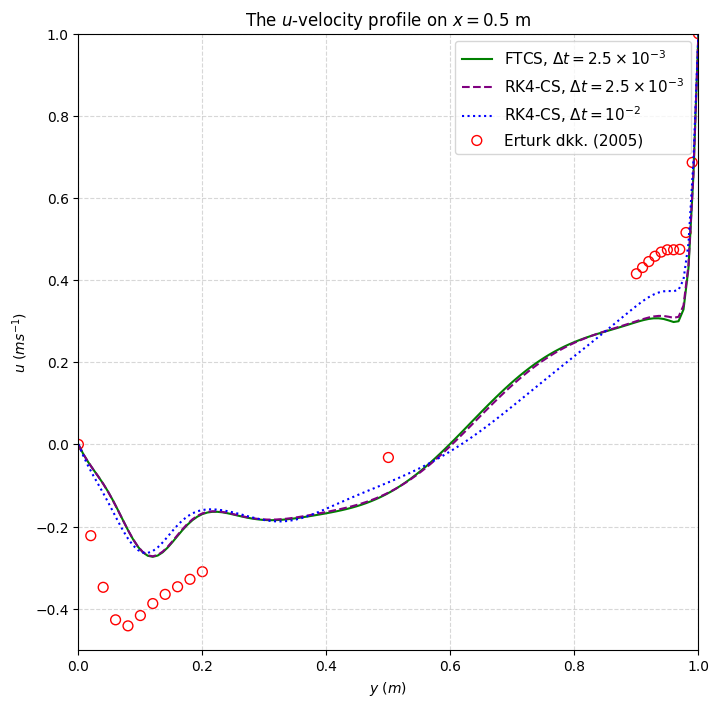

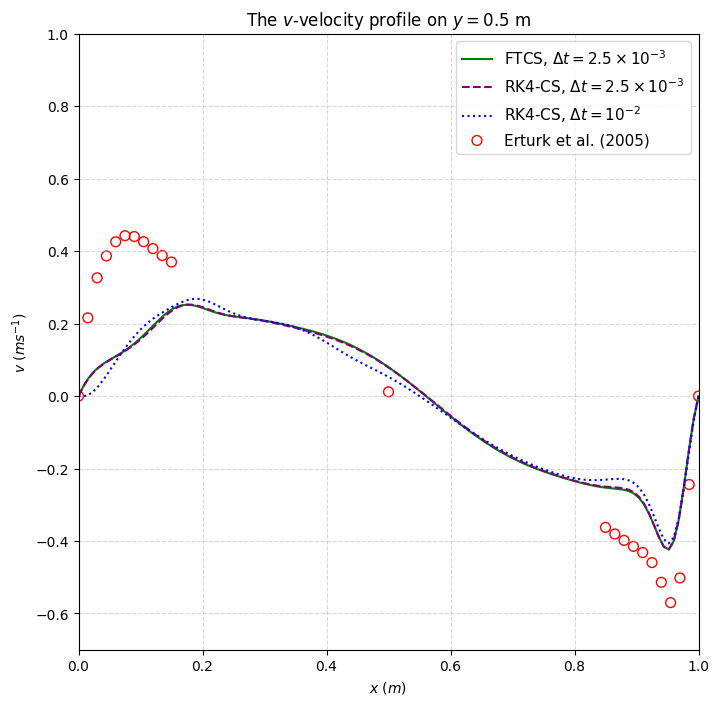

In [19]:
# plot the centerline velocity comparison
u_plot(u_ftcs_turbulen, u_rk4_turbulen, u_rk4_turbulen_ext, u_erturk_turbulen, y_turbulen, y_erturk, 'uturbulen.png')
v_plot(v_ftcs_turbulen, v_rk4_turbulen, v_rk4_turbulen_ext, v_erturk_turbulen, x_turbulen, x_erturk, 'vturbulen.png')

In [ ]:
# calculate MAPE
def mape(u_velocity, v_velocity, u_benchmark, v_benchmark, x_simulation, y_simulation):
   u_interp = np.interp(y_erturk, y_simulation, u_velocity)
   v_interp = np.interp(x_erturk, x_simulation, v_velocity)
   uv_benchmark = np.concatenate((u_benchmark, v_benchmark))
   uv_max_benchmark = np.max(np.abs(uv_benchmark))
   uv_interp = np.concatenate((u_interp, v_interp))
   err_combined = (np.abs(uv_interp - uv_benchmark) / uv_max_benchmark) * 100
   mape_combined = np.mean(err_combined)
   return mape_combined

In [ ]:
# calculate the mape
mape(u_ftcs_laminar, v_ftcs_laminar, u_erturk_laminar, v_erturk_laminar, x_laminar, y_laminar)

np.float64(2.2854810049225516)